In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

In [3]:
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")

MODELS_DIR.mkdir(parents=True, exist_ok=True)

churn_path = PROCESSED_DIR / "spotify_user_churn_clean.csv"

churn_df = pd.read_csv(churn_path)

In [4]:
X = churn_df.drop(columns=["user_id", "churned"])
y = churn_df["churned"]

In [5]:
numeric_features = [
    "avg_daily_minutes",
    "number_of_playlists",
    "skips_per_day",
    "support_tickets",
    "days_since_last_login"
]

categorical_features = [
    "subscription_type",
    "country",
    "top_genre"
]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [8]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative count:", negative_count)
print("Positive count:", positive_count)
print("Scale pos weight:", round(scale_pos_weight, 2))

Negative count: 651
Positive count: 149
Scale pos weight: 4.37


In [10]:
models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor_scaled),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            ("model", RandomForestClassifier(
                n_estimators=300,
                max_depth=5,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42
            ))
        ]
    ),

    "XGBoost": Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            ("model", XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                random_state=42
            ))
        ]
    )
}

In [11]:
def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_pred_proba)
    }

    return results

In [12]:
results = []

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)

    model_results = evaluate_model(model_name, model, X_test, y_test)
    results.append(model_results)

results_df = pd.DataFrame(results)
results_df

Training Logistic Regression...
Training Random Forest...
Training XGBoost...


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.660,0.287671,0.567568,0.381818,0.745979
1,Random Forest,0.705,0.342857,0.648649,0.448598,0.764052
2,XGBoost,0.725,0.320000,0.432432,0.367816,0.766208


In [ ]:
results_df.sort_values(by="roc_auc", ascending=False)

In [13]:
best_model_name = "Random Forest"
best_model = models[best_model_name]

best_model_path = MODELS_DIR / "best_churn_model.pkl"

joblib.dump(best_model, best_model_path)

print("Best model:", best_model_name)
print("Saved best model to:", best_model_path)

Best model: Random Forest
Saved best model to: ../models/best_churn_model.pkl


## Churn Model Comparison Results

Three models were compared for churn prediction: Logistic Regression, Random Forest, and XGBoost.

Although XGBoost achieved the highest ROC-AUC score at 0.766, Random Forest achieved the best overall business performance. It had the highest recall at 64.9% and the highest F1 score at 44.9%, while maintaining a very similar ROC-AUC score of 0.764.

For this project, recall and F1 score are more important than accuracy alone because the goal is to identify users who are likely to churn before they leave. A model with higher recall is more useful for retention strategy because it catches more at-risk users.

Random Forest was selected as the final churn model because it provided the best balance between identifying churned users and avoiding excessive false alarms. Compared with Logistic Regression, it improved recall from 56.8% to 64.9% and improved F1 score from 38.2% to 44.9%.

The final selected churn model is therefore Random Forest.

In [14]:
preprocessor = best_model.named_steps["preprocessor"]
trained_model = best_model.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(15)

,feature,importance
5,cat__subscription_type_Free,0.196627
0,num__avg_daily_minutes,0.193762
6,cat__subscription_type_Premium,0.175968
4,num__days_since_last_login,0.120942
3,num__support_tickets,0.088646
1,num__number_of_playlists,0.054353
2,num__skips_per_day,0.036510
15,cat__country_UK,0.024780
7,cat__country_AU,0.011192
22,cat__top_genre_Pop,0.010600


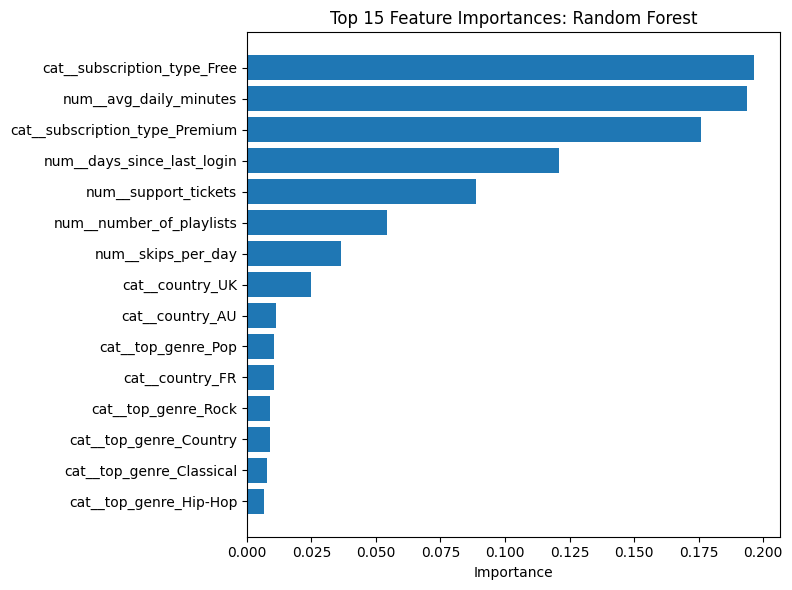

In [15]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title(f"Top 15 Feature Importances: {best_model_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()